In [2]:
import sys
sys.path.append("../scripts/")

In [3]:
import multiprocessing as mp
import warnings


import numpy as np
from scipy.stats import binned_statistic, binned_statistic_2d
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import matplotlib as mpl
from scipy.interpolate import interp1d
from scipy.signal import windows
from scipy import linalg
from nautilus import Prior, Sampler
import corner

In [4]:
Cs = sns.color_palette("colorblind")
Cp = sns.color_palette("Paired")

In [5]:
import niceplots
niceplots.initPlot()

In [6]:
from classy_wraper_for_m21cm import *
from specs import *
from meer21cm import PowerSpectrum
from meer21cm.power import get_modelpk_conv


# Compare model to simulations

In [7]:
z_func = interp1d(
    z_cen, z_count / dV_arr, kind="linear", bounds_error=False, fill_value=0
)

ps = PowerSpectrum(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        discrete_source_dndz=z_func,
        tracer_bias_2=1.5,
        tracer_bias_1=1.5,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
        sigma_beam_ch=sigma_beam_new,
        sigma_v_1= 100, # in velocity units
        sigma_v_2= 100,
    )

ps.grid_scheme = "cic"
ps.taper_function = getattr(windows, window_name)

num_gal = int(ps.survey_volume * n_gal)
ps.num_discrete_source = num_gal
ps.W_HI = np.ones_like(ps.W_HI)
ps.w_HI = np.ones_like(ps.w_HI)

ps.trim_map_to_range()
# ps.trim_gal_to_range()
ps.downres_factor_transverse = 3
ps.downres_factor_radial = 6
ps.get_enclosing_box()

ps.weights_1 = ps.counts_in_box.astype('float')
dndz_box = ps.discrete_source_dndz(ps._box_voxel_redshift)
ps.weights_field_2 = dndz_box
ps.weights_grid_2 = ((dndz_box>0)*ps.counts_in_box).astype('float') # test

In [8]:
beam = ps.beam_attenuation()

ps.sampling_resol = [
    ps.pix_resol_in_mpc,
    ps.pix_resol_in_mpc,
    ps.los_resol_in_mpc,
]
pix = ps.map_sampling()

grid = ps.gridding_compensation()
T2 = grid**2 * pix * beam

In [9]:
data = np.load("../data/power_spectra_full_sims.npz")
k, P_HIxGal = data["kmode"], data["phixgal"]
kvec = ps.k_vec
mu = ps.mu_mode

In [10]:
kmask =  np.logical_and(k<0.20, k>0)
k_bins = np.linspace(k[kmask].min(), k[kmask].max(), 15)
k_bincenters = 0.5 * (k_bins[1:] + k_bins[:-1])

N, _, bins = binned_statistic(k[kmask], [], "count", k_bins)
B1d = np.zeros((*bins.shape, *N.shape))
for i, b in enumerate(bins):
    B1d[i, b - 1] += 1
B1d *= 1/N

In [11]:
Pk_1d_Tg_sims = P_HIxGal[:, kmask] @ B1d
Nsims, Nk = Pk_1d_Tg_sims.shape

cov = 1 / (Nsims - 1) * np.einsum("ij, ik -> jk", Pk_1d_Tg_sims - Pk_1d_Tg_sims.mean(0), Pk_1d_Tg_sims - Pk_1d_Tg_sims.mean(0))
corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))

In [56]:
def BB_smooth(k, mu):
    return np.array([
        #k**-1,
        np.ones_like(k),
        k,
        k**2,
        # mu**2,
        # k * mu**2
    ])

smooth = BB_smooth(k, ps.mu_mode)
T2 = beam * pix * grid**2
X2_modes = smooth * T2
X2 = X2_modes[:, kmask] @ B1d
X = X2.T # IDK

X2.shape

(3, 14)

(array([ 82., 168., 136.,  69.,  24.,   6.,  10.,   3.,   0.,   2.]),
 array([0.20458891, 0.56357791, 0.92256692, 1.28155592, 1.64054492,
        1.99953393, 2.35852293, 2.71751194, 3.07650094, 3.43548995,
        3.79447895]),
 <BarContainer object of 10 artists>)

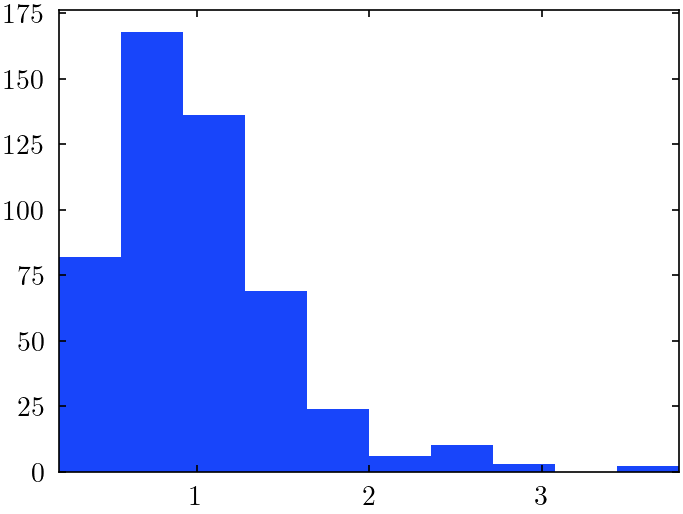

In [57]:
fudge = 1 #/ 12

invC = linalg.inv(cov * fudge)
Fisher = linalg.inv(X.T @ invC @ X)
invCmarg = invC - invC @ X @ Fisher @ X.T @ invC

chi2 = np.einsum("ij, jk, ik->i", Pk_1d_Tg_sims - Pk_1d_Tg_sims.mean(0), invCmarg, Pk_1d_Tg_sims - Pk_1d_Tg_sims.mean(0))
plt.hist(chi2 / (X2.shape[1] - X2.shape[0]))

In [66]:
fudge = 1 / 120
cov_fudged = cov * fudge

invC = linalg.inv(cov_fudged)
Fisher = linalg.inv(X.T @ invC @ X)
invCmarg12 = invC - invC @ X @ Fisher @ X.T @ invC

# Test BAO sampling pipeline

In [67]:
fid_bao_pars = {
    "alpha_parr" :1,
    "alpha_perp" :1,
    "sigma_p" :ps.deltav_to_deltar(100), # Mpc
    "sigma_v" :ps.deltav_to_deltar(100), # Mpc
    "bias":1.5,
    "bias_2":1.5,
}

classcosmo = Class_cosmo_model({})
baocosmo = power_spectrum_from_baopars(classcosmo, fid_bao_pars, desi_like_bao=True)
Pk_3d_fid = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")

Pk_3d_Tg_fid = Pk_3d_fid[1, ...] * T2 * ps.average_hi_temp
Pk_3d_Tg_fid[~kmask] = 0.0
Pk_3d_Tg_fid = get_modelpk_conv(Pk_3d_Tg_fid, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
Pk_1d_Tg_fid = Pk_3d_Tg_fid[kmask] @ B1d

{}


In [68]:
def loglike(pars):
    bao_pars = fid_bao_pars.copy()
    bao_pars.update(pars)

    baocosmo = power_spectrum_from_baopars(classcosmo, bao_pars, desi_like_bao=True)
    Pk_3d_true = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")

    Pk_3d_Tg_true = Pk_3d_true[1,...] * T2 * ps.average_hi_temp
    Pk_3d_Tg_true[~kmask] = 0.0
    Pk_3d_Tg_true = get_modelpk_conv(Pk_3d_Tg_true, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    Pk_1d_Tg_true = Pk_3d_Tg_true[kmask] @ B1d
    
    Delta = Pk_1d_Tg_true - Pk_1d_Tg_fid
    chi2 = np.einsum("i, ij, j", Delta, invCmarg12, Delta)
    return -0.5 * chi2

In [69]:
loglike({"alpha_parr":2})

-18.503613145447826

In [70]:
prior = Prior()
prior.add_parameter("bias", (0.1, 10))
prior.add_parameter("bias_2", (0.1, 10))
# prior.add_parameter("sigma_p", (1, 10)) # our scalecuts are very conservative rn but probably we still need to vary this
prior.add_parameter("alpha_perp", (0.1, 5))
prior.add_parameter("alpha_parr", (0.1, 5))

sampler = Sampler(prior, loglike, n_live=2000, pool=12, filepath="../data/chain_v1_1D_Tg_fudged120_desi_like_simple_bb.hdf5")

In [71]:
warnings.filterwarnings('ignore') #...

In [72]:
sampler.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 20     | 1        | 4        | 46116    | N/A    | 18221 | -9.21    


True

hello


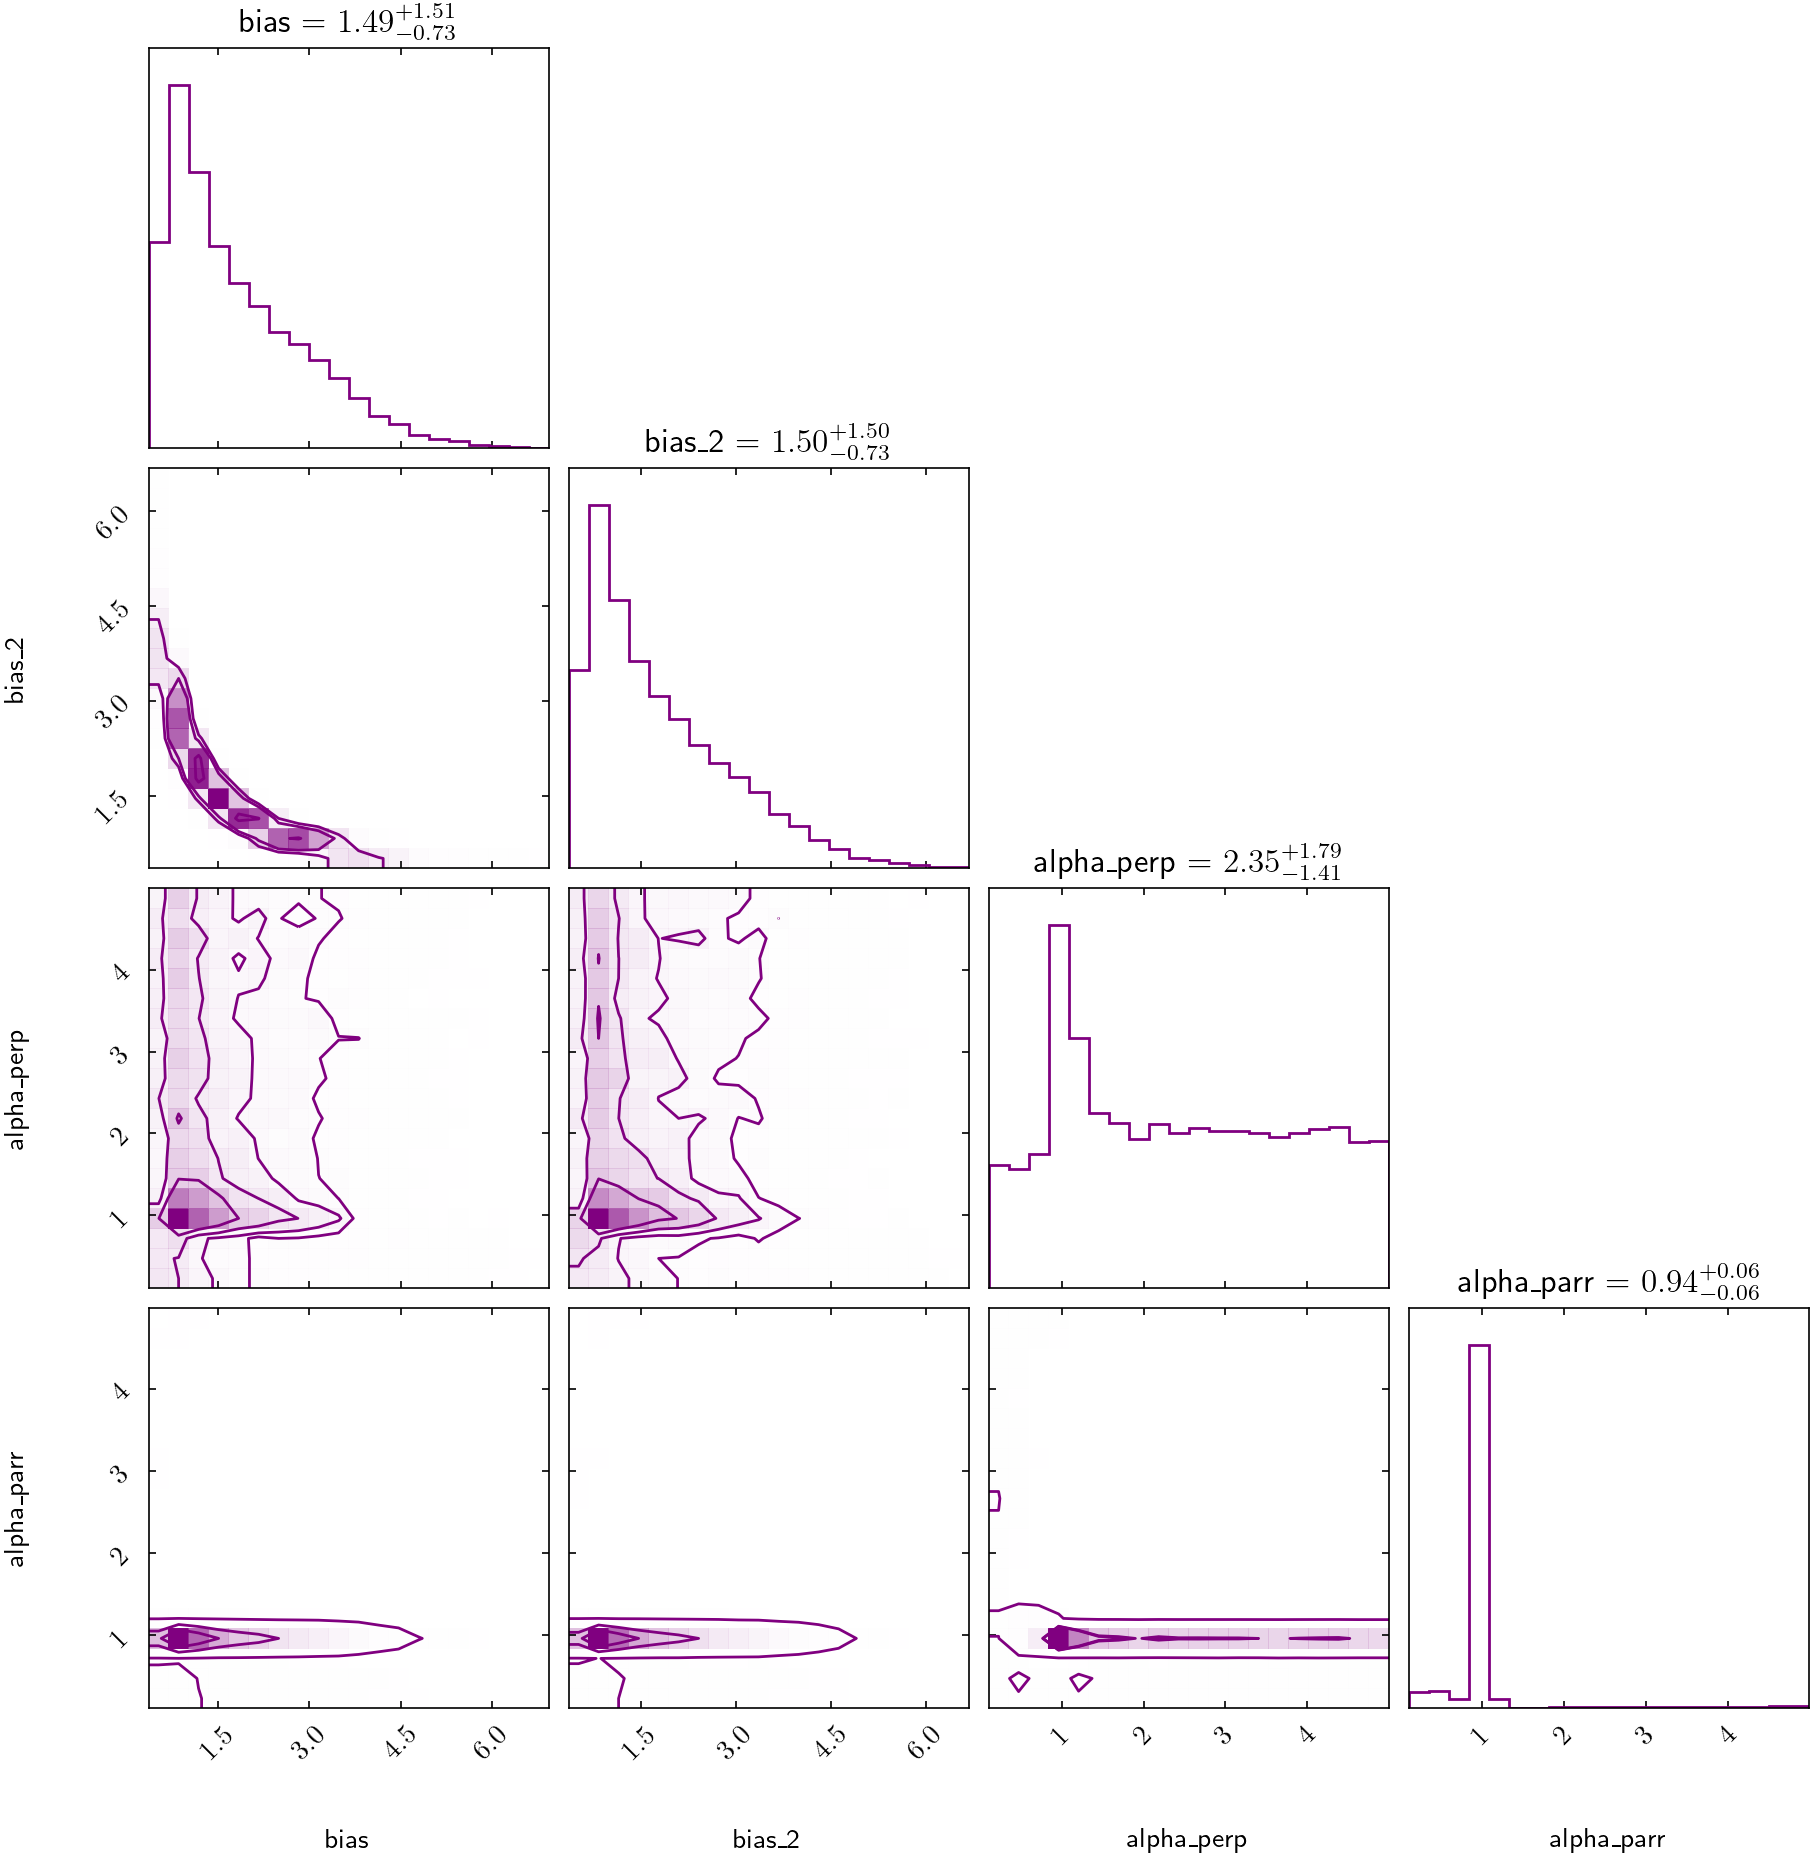

In [73]:
points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=prior.keys, color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), show_titles=True,)
print("hello")